# Main Fig 2 — AUROC vs K (iso-compute)

**Data**: `heatmap_df_test.csv` per task/head from `final_results/phase0_v3/inference/`  
**Tasks (main)**: 3 representative tasks — age, sleep efficiency, sex classification  
**Head**: Transformer  
**Layout**: 1 row × 3 cols (panels a, b, c)  

Three tasks chosen to illustrate distinct K-aggregation behaviours:  
- **(a) age_class** — iso-compute substitutability (upper L curves converge)  
- **(b) sleep_efficiency_binary** — context irreplaceable (curves stay separated)  
- **(c) sex_binary** — K-saturation speed varies with L  

For supplementary (all main tasks), see the commented block at the end.

In [1]:
%matplotlib inline

In [2]:
import sys
from pathlib import Path

# ── Workspace root: auto-detect by looking for final_results/ ─────────────────
def _find_workspace():
    """Walk up from CWD until we find a directory containing final_results/."""
    candidate = Path.cwd().resolve()
    for _ in range(10):
        if (candidate / "final_results").exists():
            return candidate
        if candidate.parent == candidate:
            break
        candidate = candidate.parent
    # Explicit fallback (edit this if auto-detect fails)
    return Path("/Users/boshra/NSRR-workspace").resolve()

WORKSPACE_ROOT = _find_workspace()
NSRR_TOOLS     = WORKSPACE_ROOT / "NSRR-tools"
FINAL_RESULTS  = WORKSPACE_ROOT / "final_results"
PAPER_FIGURES  = NSRR_TOOLS / "results" / "paper_figures"
FINAL_OUT      = PAPER_FIGURES / "final_npj"
FINAL_OUT.mkdir(parents=True, exist_ok=True)

# Add utils to path (notebooks/utils/)
_nb_dir = PAPER_FIGURES / "notebooks_npj"
sys.path.insert(0, str(_nb_dir))

from utils.style import (
    apply_tbme_style, save_figure, FULL_W, HALF_W,
    MAIN_TASKS, SUPP_TASKS, ALL_TASKS, BINARY_MAIN,
    HEAD_STYLE, TASK_LABEL, FONT_ANNOT, FONT_BASE, FONT_LABEL, FONT_TITLE,
)
from utils.data import set_root, load_analysis, load_heatmap, load_parquets
from utils import panels

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

set_root(WORKSPACE_ROOT)
apply_tbme_style()

# ── Confirm the workspace root is correct ─────────────────────────────────────
_ok = (WORKSPACE_ROOT / "final_results").exists()
print(f"WORKSPACE_ROOT : {WORKSPACE_ROOT}")
print(f"final_results/ : {'✓ found' if _ok else '✗ NOT FOUND — edit _find_workspace() fallback'}")

WORKSPACE_ROOT : /Users/boshra/NSRR-workspace
final_results/ : ✓ found


In [3]:
# Panel labeling helper
def add_panel_label(ax, label, x=0.02, y=0.97):
    ax.text(x, y, label, transform=ax.transAxes,
            fontsize=10, fontweight="bold", va="top", fontfamily="serif")

In [4]:
HEAD   = "transformer"
METRIC = "auroc"

# ── Main figure: 3 tasks showing distinct K-aggregation behaviours ──────────
# (a) age_class:                iso-compute substitutability
#                               (80m/120m/240m converge at K_max: 0.900, 0.902, 0.905)
# (b) sleep_efficiency_binary:  context irreplaceable
#                               (each L step +0.07–0.10 even at large K;
#                                K_max at 30s = 0.707 vs K=1 at 240m = 0.768)
# (c) sex_binary:               K-saturation speed varies with L
#                               (needs K≈1000 at 30s → K=4 at 120m → K=2 at 240m)
TASKS  = ["age_class", "sleep_efficiency_binary", "sex_binary"]
N_COLS = 3
N_ROWS = 1   # single row for 3-panel figure

# Load heatmap DataFrames
hmaps = {t: load_heatmap("phase0_v3", t, HEAD) for t in TASKS}
print({t: len(v) for t, v in hmaps.items()})

{'age_class': 81, 'sleep_efficiency_binary': 85, 'sex_binary': 76}


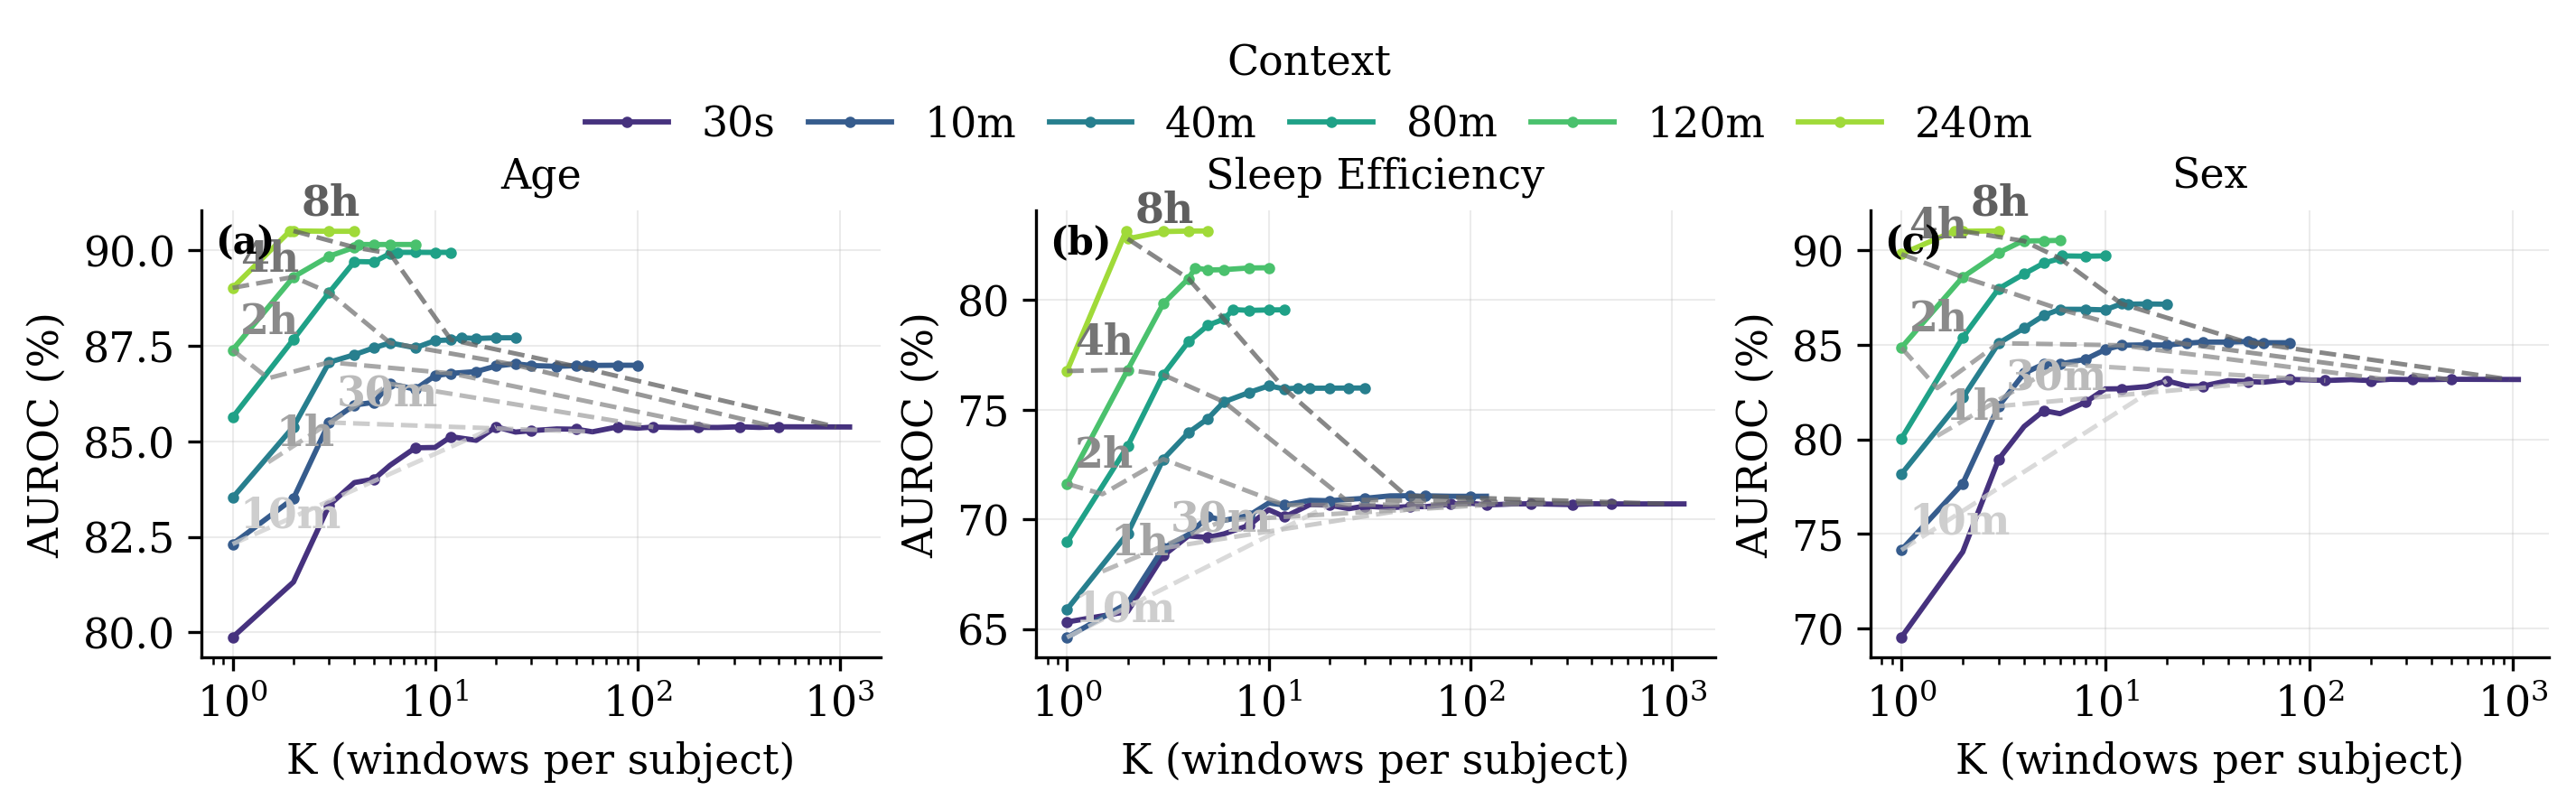

In [5]:
# ROW_H controls how tall each row is (inches).
# Increase it to make panels bigger — try 2.5 or 3.0.
ROW_H = 2.5  # single-row figure

# Build a subplot_mosaic layout so the last (incomplete) row is centred.
# Each panel label is repeated across 2 virtual columns; "." = ignored cell.
#
# Example for 5 tasks, N_COLS=3 (6 virtual columns):
#   a a b b c c
#   . d d e e .
labels  = [chr(97 + i) for i in range(len(TASKS))]
n_last  = len(TASKS) % N_COLS or N_COLS   # panels in the last row
n_full  = len(TASKS) // N_COLS

mosaic = []
for row in range(n_full):
    row_labels = labels[row * N_COLS : (row + 1) * N_COLS]
    mosaic.append([lbl for lbl in row_labels for _ in range(2)])

if n_last < N_COLS:   # incomplete → centre it
    last_labels = labels[n_full * N_COLS:]
    pad = N_COLS - n_last          # ignored cells on each side
    mosaic.append(
        ["."] * pad +
        [lbl for lbl in last_labels for _ in range(2)] +
        ["."] * pad
    )

fig, axd = plt.subplot_mosaic(mosaic, figsize=(FULL_W+2.5, N_ROWS * ROW_H+0.5))

for i, (lbl, task) in enumerate(zip(labels, TASKS)):
    ax = axd[lbl]
    panels.kvsk_panel(ax, hmaps[task], col=METRIC, show_legend=False)
    ax.set_title(TASK_LABEL[task], fontsize=FONT_TITLE)
    add_panel_label(ax, f"({chr(97+i)})")

# Add shared legend BEFORE tight_layout so rect can reserve space for it.
# loc="upper center" + bbox_to_anchor=(0.5, 1.0): top-center of legend box
# sits at the top edge of the figure; legend hangs down into the reserved area.
_handles, _leg_labels = axd[labels[0]].get_legend_handles_labels()
fig.legend(_handles, _leg_labels,
           title="Context", loc="upper center",
           ncol=len(_handles), fontsize=FONT_BASE, title_fontsize=FONT_BASE,
           frameon=False, bbox_to_anchor=(0.5, 1.01),
           handlelength=2.0, columnspacing=0.8)

# rect=[0,0,1,0.88] reserves top 12% for the legend; panels fill the rest.
fig.tight_layout(h_pad=1.5, w_pad=0.5, rect=[0, 0, 1, 0.88])
plt.show()

In [6]:
# ── Run when figure looks good ──────────────────────────────────
save_figure(fig, FINAL_OUT, "main_fig2_kvsk")
import shutil
shutil.copy(FINAL_OUT / "main_fig2_kvsk.pdf",
            WORKSPACE_ROOT / "npj_digital_medicine_submission" / "main_fig2_kvsk.pdf")
print("Saved + copied → npj_digital_medicine_submission/main_fig2_kvsk.pdf")

  saved → /Users/boshra/NSRR-workspace/NSRR-tools/results/paper_figures/final_npj/main_fig2_kvsk.pdf
Saved + copied → npj_digital_medicine_submission/main_fig2_kvsk.pdf


## ── SUPPLEMENTARY VERSION ─────────────────────────────────────────────────────

**Target:** `sfig_kvsk.pdf`  
**→ also copy to:** `npj_digital_medicine_submission/sfig_kvsk.pdf`  

Shows AUROC vs K (same `kvsk_panel`, all context lengths, iso-compute lines)  
for **all 5 main tasks**.  Uncomment the cell below and run to regenerate.

> **Pattern for all main figures:** every main figure notebook ends with a block
> like this. Uncomment → run → the supplementary PDF updates automatically.

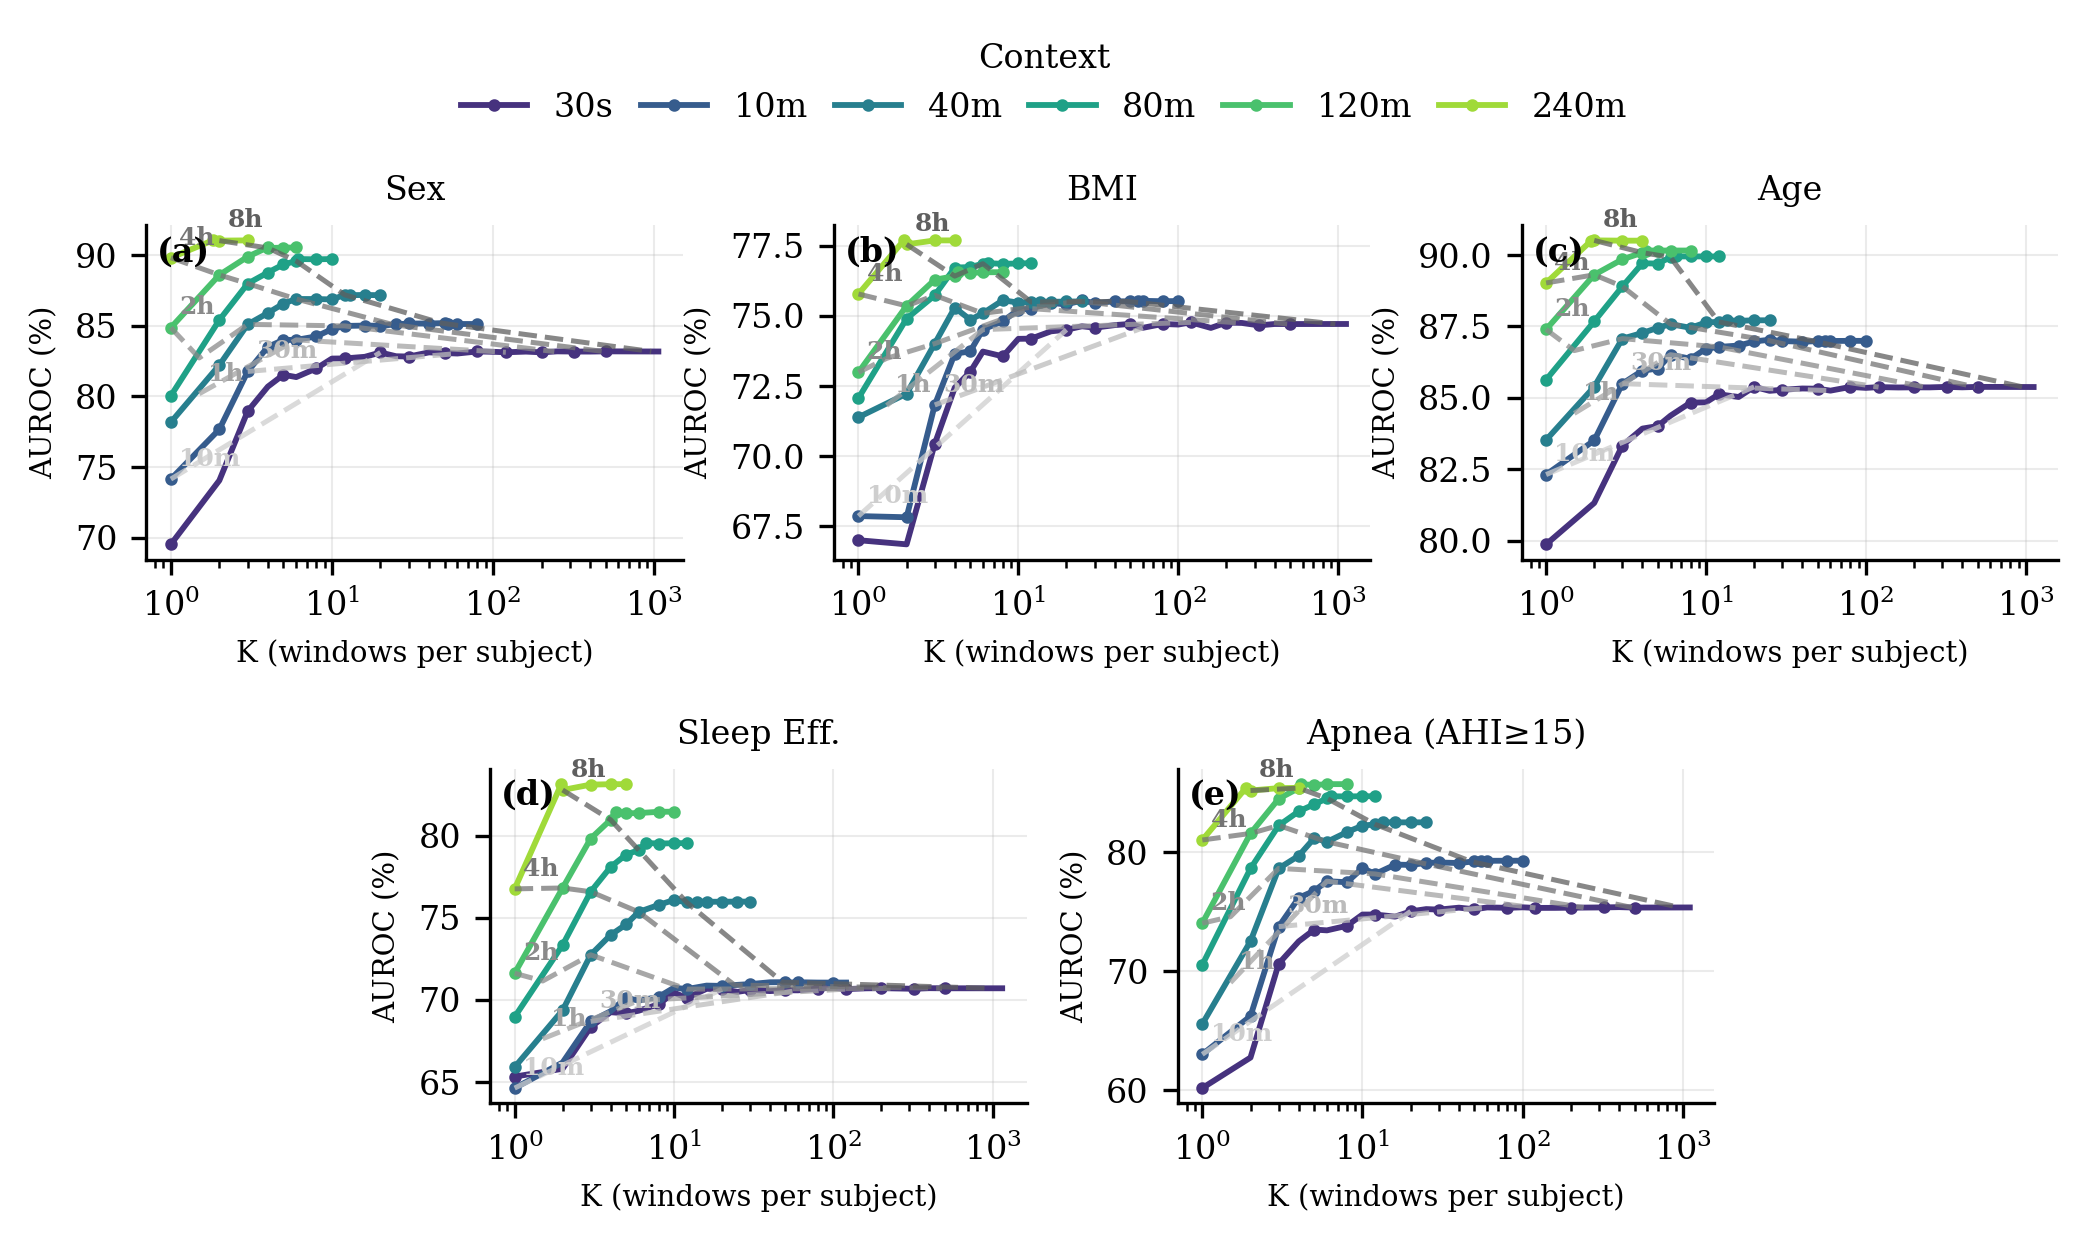

In [7]:
# ══════════════════════════════════════════════════════════════════════════════
# SUPPLEMENTARY  sfig_kvsk — AUROC vs K, all tasks
# Target: sfig_kvsk.pdf  (copy to npj_digital_medicine_submission/ when done)
# To regenerate: uncomment ALL lines below, then run this cell.
# ══════════════════════════════════════════════════════════════════════════════

SUPP_TASKS = MAIN_TASKS   # all 5 main tasks
SUPP_NCOLS = 3
SUPP_NROWS = (len(SUPP_TASKS) + SUPP_NCOLS - 1) // SUPP_NCOLS
SUPP_ROW_H = 2.1

supp_hmaps = {t: load_heatmap('phase0_v3', t, HEAD) for t in SUPP_TASKS}

_labels = [chr(97 + i) for i in range(len(SUPP_TASKS))]
_n_last = len(SUPP_TASKS) % SUPP_NCOLS or SUPP_NCOLS
_n_full = len(SUPP_TASKS) // SUPP_NCOLS

_mosaic = []
for _row in range(_n_full):
    _row_labels = _labels[_row * SUPP_NCOLS : (_row + 1) * SUPP_NCOLS]
    _mosaic.append([lbl for lbl in _row_labels for _ in range(2)])
if _n_last < SUPP_NCOLS:
    _last = _labels[_n_full * SUPP_NCOLS:]
    _pad  = SUPP_NCOLS - _n_last
    _mosaic.append(['.'] * _pad +
                   [lbl for lbl in _last for _ in range(2)] +
                   ['.'] * _pad)

fig_supp, axd_supp = plt.subplot_mosaic(
    _mosaic, figsize=(FULL_W, SUPP_NROWS * SUPP_ROW_H)
)
for _i, (_lbl, _task) in enumerate(zip(_labels, SUPP_TASKS)):
    _ax = axd_supp[_lbl]
    panels.kvsk_panel(_ax, supp_hmaps[_task], col=METRIC, show_legend=False)
    _ax.set_title(TASK_LABEL[_task], fontsize=FONT_TITLE)
    add_panel_label(_ax, f'({chr(97+_i)})')
_sh, _sl = axd_supp[_labels[0]].get_legend_handles_labels()
fig_supp.legend(_sh, _sl, title='Context', loc='upper center',
                ncol=len(_sh), fontsize=FONT_BASE, title_fontsize=FONT_BASE,
                frameon=False, bbox_to_anchor=(0.5, 0.98),
                handlelength=2.0, columnspacing=0.8)
fig_supp.tight_layout(h_pad=1.5, w_pad=1.0, rect=[0, 0, 1, 0.88])
plt.show()

In [ ]:
# Save and copy to npj_digital_medicine_submission
save_figure(fig_supp, FINAL_OUT, 'sfig_kvsk')
import shutil
_submission = WORKSPACE_ROOT / 'npj_digital_medicine_submission'
shutil.copy(FINAL_OUT / 'sfig_kvsk.pdf',
            _submission / 'sfig_kvsk.pdf')
print('Saved + copied → npj_digital_medicine_submission/sfig_kvsk.pdf')